In [1]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import get_relevant_output_layers, compute_samples_sizes, load_npz_as_dict, get_triu_perms, get_lagplot_subset
from general_utils.static_dRSA import init_whole_neural_RDM, similarity_subsamples_par
from general_utils.plots import truncate_colormap, plot_subsamples

In [2]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'paul' 
    date: str = '230204'
    model_name: str = 'vit_l_16'
    layer_name: str = 'blocks.16.mlp.fc2'
    pkg: str = 'timm'
    img_size: int = 384
    brain_area: str = 'AIT'
    dummy_areas = ['V1', 'V4', 'IT']
    max_size: int = 2500
    n_trials: int = 4377
    step_samples: int = 100 # of how many samples we jump every time
    similarity_measure: str = 'cosine'
    pooling: str = 'mean'
    new_fs: int = 100 # Hz
    n_iter: int = 100 # how many time we repeat the sampling
    RDM_metric: str = 'cosine'
    RSA_metric: str = 'correlation'
    fig_dir: str = "/Users/tizianocausin/gdrive/figures_papers/research_plan"
    title_fontsize=25
    labels_fontsize = 20
    ticks_fontsize = 15
    legend_fontsize=13
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
brain_areas = ['V1', 'V2', 'V3', 'PIT', 'CIT', 'AIT']

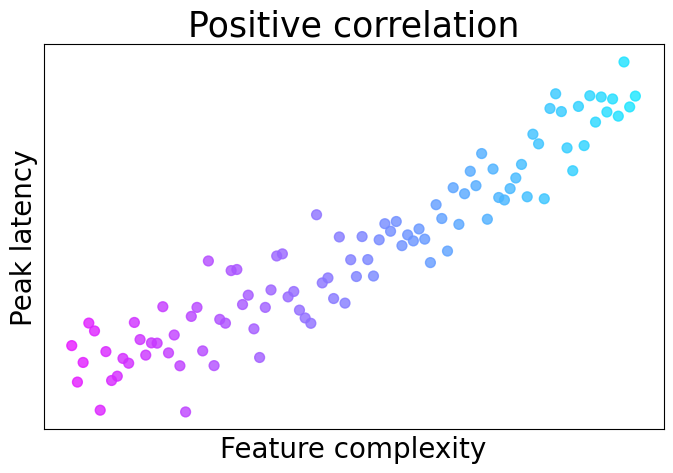

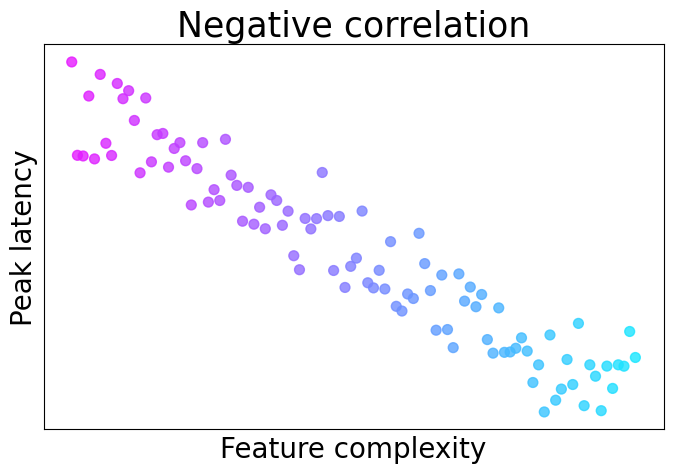

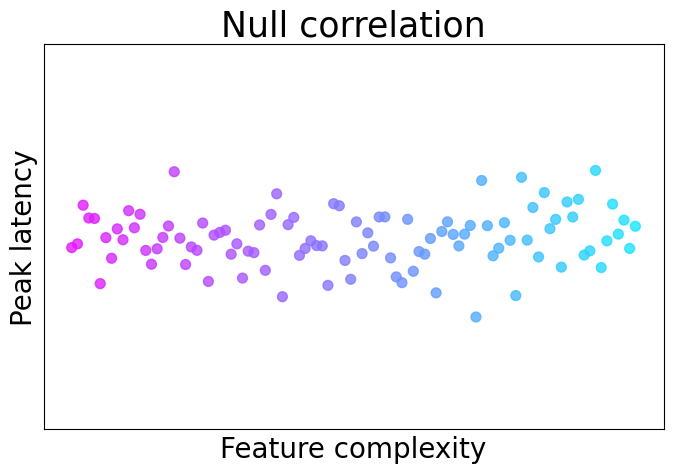

In [106]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# positive correlation
x = np.linspace(0, 10, 100)
y = 3 * x + 5 + np.random.normal(scale=3, size=100)
# y = -y
# Create gradient colors (light blue → purple)
cmap = plt.cm.cool
colors = cmap(np.linspace(0.1, 0.9, len(x)))[::-1]  # reverse for purple → light blue
fig, ax = plt.subplots(figsize=(8, 5))
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_linewidth(2.5)
# ax.spines['left'].set_linewidth(2.5)
ax.scatter(x, y, color=colors, s=50, alpha=0.8)
# ax.set_xticks([0, 5, 9])
# ax.set_xticklabels([ .1, .5,  .8])
# ax.set_yticks(np.array([-40, -30, -20, -10, 0])[::-1]*(-1))
# ax.set_yticklabels([0, 50, 100, 150, 200])
# ax.tick_params( labelsize=20)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("Feature complexity", fontsize=cfg.labels_fontsize)
ax.set_ylabel("Peak latency", fontsize=cfg.labels_fontsize)
ax.set_title("Positive correlation", fontsize=cfg.title_fontsize)
plt.savefig(f"{cfg.fig_dir}/positive_correlation.pdf")
plt.show()

# negative correlation
x = np.linspace(0, 10, 100)
y = -3 * x + 5 + np.random.normal(scale=3, size=100)
# y = -y
# Create gradient colors (light blue → purple)
cmap = plt.cm.cool
colors = cmap(np.linspace(0.1, 0.9, len(x)))[::-1]  # reverse for purple → light blue
fig, ax = plt.subplots(figsize=(8, 5))
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_linewidth(2.5)
# ax.spines['left'].set_linewidth(2.5)
ax.scatter(x, y, color=colors, s=50, alpha=0.8)
# ax.set_xticks([0, 5, 9])
# ax.set_xticklabels([ .1, .5,  .8])
# ax.set_yticks(np.array([-40, -30, -20, -10, 0])[::-1]*(-1))
# ax.set_yticklabels([0, 50, 100, 150, 200])
# ax.tick_params( labelsize=20)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("Feature complexity", fontsize=cfg.labels_fontsize)
ax.set_ylabel("Peak latency", fontsize=cfg.labels_fontsize)
ax.set_title("Negative correlation", fontsize=cfg.title_fontsize)
plt.savefig(f"{cfg.fig_dir}/negative_correlation.pdf")
plt.show()

# null correlation
x = np.linspace(0, 10, 100)
y =  20 + np.random.normal(scale=3, size=100)
# Create gradient colors (light blue → purple)
cmap = plt.cm.cool
colors = cmap(np.linspace(0.1, 0.9, len(x)))[::-1]  # reverse for purple → light blue
fig, ax = plt.subplots(figsize=(8, 5))
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_linewidth(2.5)
# ax.spines['left'].set_linewidth(2.5)
ax.scatter(x, y, color=colors, s=50, alpha=0.8)
ax.set_ylim([0, 40])
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_xlabel("Feature complexity", fontsize=cfg.labels_fontsize)
ax.set_ylabel("Peak latency", fontsize=cfg.labels_fontsize)
ax.set_title("Null correlation", fontsize=cfg.title_fontsize)
plt.savefig(f"{cfg.fig_dir}/null_correlation.pdf")
plt.show()

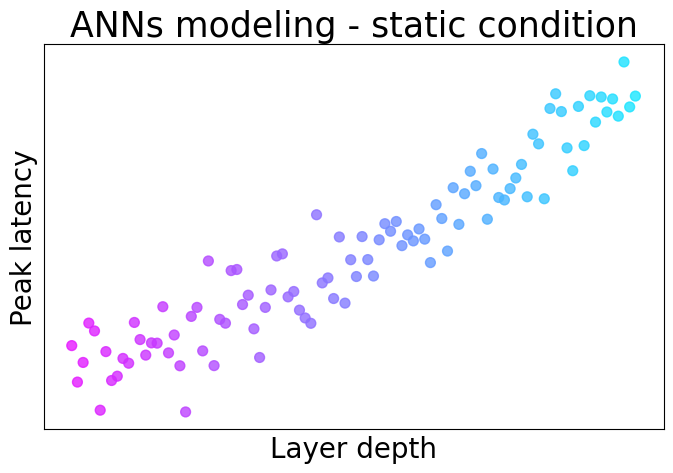

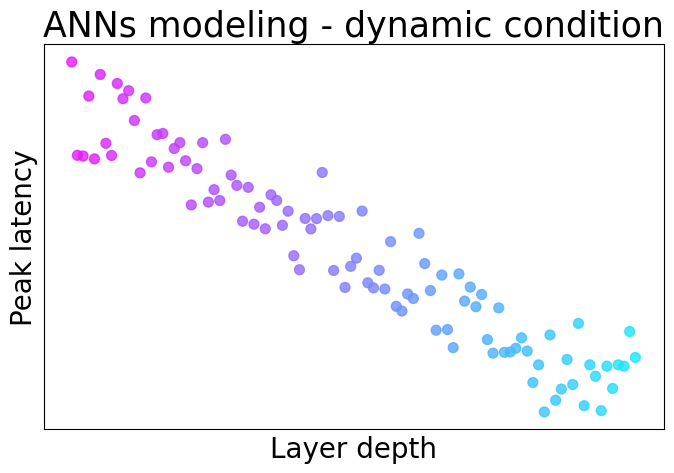

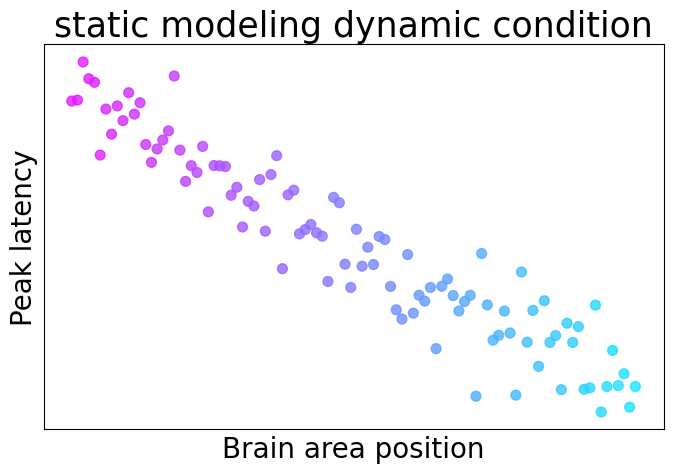

In [180]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# positive correlation
x = np.linspace(0, 10, 100)
y = 3 * x + 5 + np.random.normal(scale=3, size=100)
# y = -y
# Create gradient colors (light blue → purple)
cmap = plt.cm.cool
colors = cmap(np.linspace(0.1, 0.9, len(x)))[::-1]  # reverse for purple → light blue
fig, ax = plt.subplots(figsize=(8, 5))
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_linewidth(2.5)
# ax.spines['left'].set_linewidth(2.5)
ax.scatter(x, y, color=colors, s=50, alpha=0.8)
# ax.set_xticks([0, 5, 9])
# ax.set_xticklabels([ .1, .5,  .8])
# ax.set_yticks(np.array([-40, -30, -20, -10, 0])[::-1]*(-1))
# ax.set_yticklabels([0, 50, 100, 150, 200])
# ax.tick_params( labelsize=20)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("Layer depth", fontsize=cfg.labels_fontsize)
ax.set_ylabel("Peak latency", fontsize=cfg.labels_fontsize)
ax.set_title("ANNs modeling - static condition", fontsize=cfg.title_fontsize)
plt.savefig(f"{cfg.fig_dir}/static_cond_corr.pdf")
plt.show()

# negative correlation
x = np.linspace(0, 10, 100)
y = -3 * x + 5 + np.random.normal(scale=3, size=100)
# y = -y
# Create gradient colors (light blue → purple)
cmap = plt.cm.cool
colors = cmap(np.linspace(0.1, 0.9, len(x)))[::-1]  # reverse for purple → light blue
fig, ax = plt.subplots(figsize=(8, 5))
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_linewidth(2.5)
# ax.spines['left'].set_linewidth(2.5)
ax.scatter(x, y, color=colors, s=50, alpha=0.8)
# ax.set_xticks([0, 5, 9])
# ax.set_xticklabels([ .1, .5,  .8])
# ax.set_yticks(np.array([-40, -30, -20, -10, 0])[::-1]*(-1))
# ax.set_yticklabels([0, 50, 100, 150, 200])
# ax.tick_params( labelsize=20)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("Layer depth", fontsize=cfg.labels_fontsize)
ax.set_ylabel("Peak latency", fontsize=cfg.labels_fontsize)
ax.set_title("ANNs modeling - dynamic condition", fontsize=cfg.title_fontsize)
plt.savefig(f"{cfg.fig_dir}/dynamic_cond_corr.pdf")
plt.show()

# negative correlation
x = np.linspace(0, 10, 100)
y = -3 * x + 5 + np.random.normal(scale=3, size=100)
# y = -y
# Create gradient colors (light blue → purple)
cmap = plt.cm.cool
colors = cmap(np.linspace(0.1, 0.9, len(x)))[::-1]  # reverse for purple → light blue
fig, ax = plt.subplots(figsize=(8, 5))
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_linewidth(2.5)
# ax.spines['left'].set_linewidth(2.5)
ax.scatter(x, y, color=colors, s=50, alpha=0.8)
# ax.set_xticks([0, 5, 9])
# ax.set_xticklabels([ .1, .5,  .8])
# ax.set_yticks(np.array([-40, -30, -20, -10, 0])[::-1]*(-1))
# ax.set_yticklabels([0, 50, 100, 150, 200])
# ax.tick_params( labelsize=20)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("Brain area position", fontsize=cfg.labels_fontsize)
ax.set_ylabel("Peak latency", fontsize=cfg.labels_fontsize)
ax.set_title("static modeling dynamic condition", fontsize=cfg.title_fontsize)
plt.savefig(f"{cfg.fig_dir}/static_dynamic_cond_corr.pdf")
plt.show()

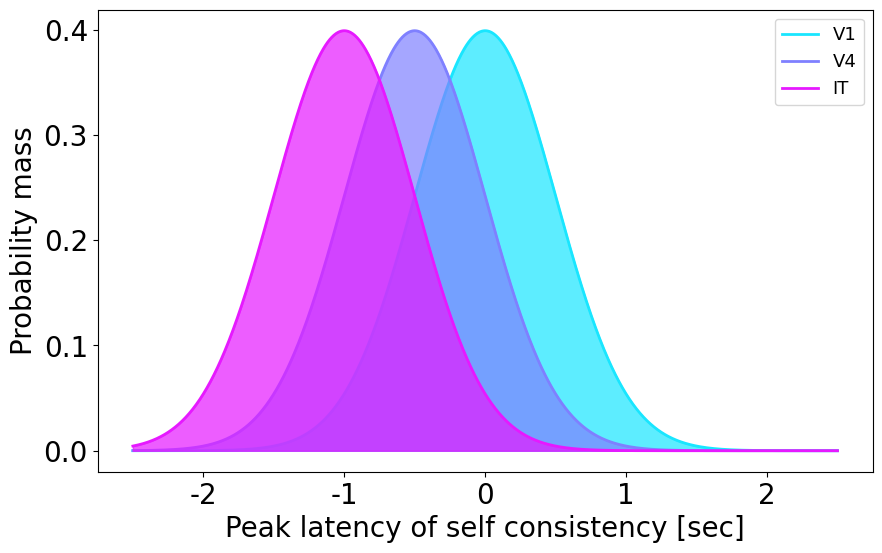

In [159]:
x = np.linspace(-5, 5, 1000)
means = [0, -1, -2]
std = 1
cmap=plt.cm.cool_r
colors = cmap(np.linspace(0.1, 0.9, len(means)))[::-1]  # pick evenly spaced colors
plt.figure(figsize=(10, 6))
for mean, color, a in zip(means, colors, cfg.dummy_areas):
    y = (1 / (std * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x-mean)/std)**2)
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    plt.style.use('default')  # prevent style interference
    plt.plot(x, y, linewidth=2, color=color, zorder=1, label=a)
    ax = plt.gca()
    ax.tick_params(labelsize=cfg.labels_fontsize)
    ax.set_xticks([-4, -2, 0, 2, 4])
    ax.set_xticklabels([-2, -1, 0, 1, 2])
    plt.fill_between(x, y, 0, color=color, alpha=.7, zorder=1)
    plt.box('off')
plt.xlabel("Peak latency of self consistency [sec]", fontsize=cfg.labels_fontsize)
plt.ylabel("Probability mass", fontsize=cfg.labels_fontsize)
plt.legend(fontsize=cfg.legend_fontsize)
plt.savefig(f"{cfg.fig_dir}/prob_distributions.pdf")
plt.show()

In [171]:
f"{cfg.fig_dir}/statc_dynamic_lagplots.pdf"

'/Users/tizianocausin/gdrive/figures_papers/statc_dynamic_lagplots.pdf'

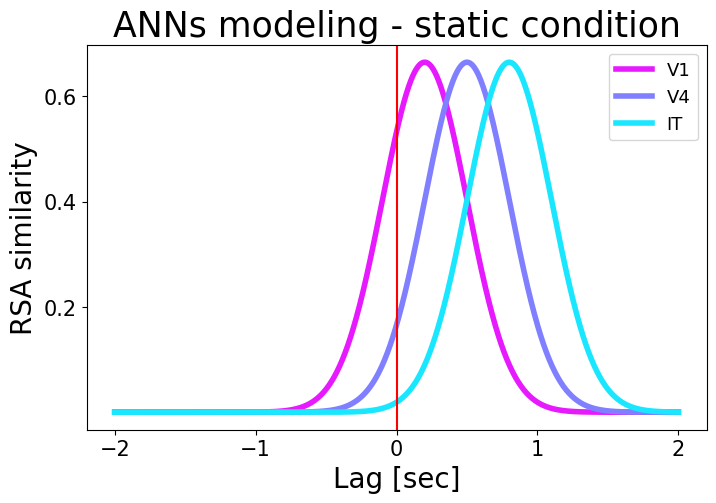

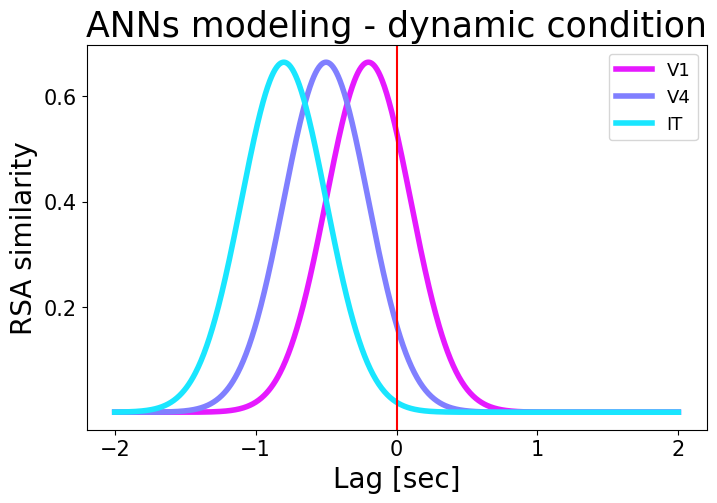

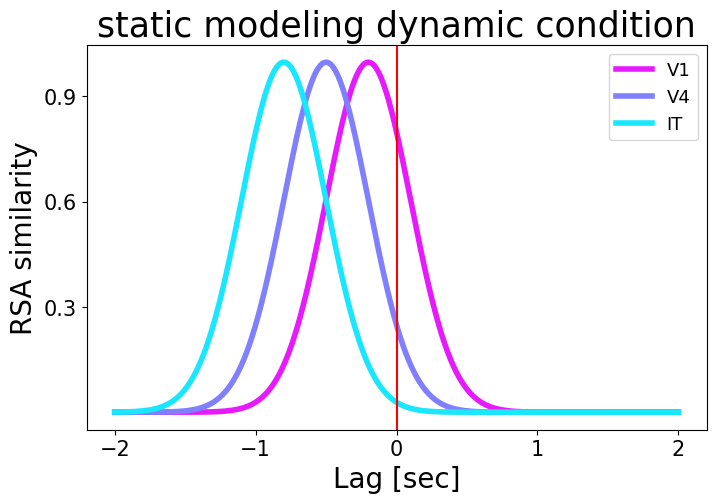

In [178]:
x = np.linspace(-2, 2, 1000)
means = [0.2, .5, .8]
std = .3

# Choose a colormap that goes from blue → purple
cmap = plt.cm.cool
colors = cmap(np.linspace(0.1, 0.9, len(means)))[::-1]  # pick evenly spaced colors

fig, ax = plt.subplots(figsize=(8, 5))

for mean, color, a in zip(means, colors, cfg.dummy_areas):
    y = (1 / (std * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x-mean)/std)**2)
    ax.plot(x, y, linewidth=4, color=color, label=a)
plt.legend(fontsize=cfg.legend_fontsize)
# Format plot
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_linewidth(2.5)
# ax.spines['left'].set_linewidth(2.5)

ax.set_yticks([.4, .8, 1.2])
ax.set_yticklabels([.2, .4, .6])
ax.set_xticks([-2, -1, 0, 1, 2])
ax.tick_params(labelsize=cfg.ticks_fontsize)
ax.set_xlabel("Lag [sec]", fontsize=cfg.labels_fontsize)
ax.set_ylabel("RSA similarity", fontsize=cfg.labels_fontsize)
ax.set_title("ANNs modeling - static condition", fontsize=cfg.title_fontsize)
plt.axvline(0, color='r')
plt.savefig(f"{cfg.fig_dir}/static_lagplots_ANNs.pdf")
plt.show()

means = [-0.2, -.5, -.8]
std = .3

# Choose a colormap that goes from blue → purple
cmap = plt.cm.cool
colors = cmap(np.linspace(0.1, 0.9, len(means)))[::-1]  # pick evenly spaced colors

fig, ax = plt.subplots(figsize=(8, 5))

for mean, color, a in zip(means, colors, cfg.dummy_areas):
    y = (1 / (std * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x-mean)/std)**2)
    ax.plot(x, y, linewidth=4, color=color, label=a)
plt.legend(fontsize=cfg.legend_fontsize)
# Format plot
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_linewidth(2.5)
# ax.spines['left'].set_linewidth(2.5)

ax.set_yticks([.4, .8, 1.2])
ax.set_yticklabels([.2, .4, .6])
ax.set_xticks([-2, -1, 0, 1, 2])
ax.tick_params(labelsize=cfg.ticks_fontsize)
ax.set_xlabel("Lag [sec]", fontsize=cfg.labels_fontsize)
ax.set_ylabel("RSA similarity", fontsize=cfg.labels_fontsize)
ax.set_title("ANNs modeling - dynamic condition", fontsize=cfg.title_fontsize)
plt.axvline(0, color='r')
plt.savefig(f"{cfg.fig_dir}/dynamic_lagplots_ANNs.pdf")
plt.show()

means = [-0.2, -.5, -.8]
std = .3
fig, ax = plt.subplots(figsize=(8, 5))
for mean, color, a in zip(means, colors, cfg.dummy_areas):
    y = (1 / (std * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x-mean)/std)**2)
    ax.plot(x, y, linewidth=4, color=color, label=a)
plt.legend(fontsize=cfg.legend_fontsize)
ax.set_yticks([.4, .8, 1.2])
ax.set_yticklabels([.3, .6, .9])
ax.set_xticks([-2, -1, 0, 1, 2])
ax.tick_params(labelsize=cfg.ticks_fontsize)
ax.set_xlabel("Lag [sec]", fontsize=cfg.labels_fontsize)
ax.set_ylabel("RSA similarity", fontsize=cfg.labels_fontsize)
ax.set_title("static modeling dynamic condition", fontsize=cfg.title_fontsize)
plt.axvline(0, color='r')
plt.savefig(f"{cfg.fig_dir}/static_dynamic_lagplots.pdf")
plt.show()

In [5]:
from general_utils.utils import load_img_natraster, BrainAreas
natraster = load_img_natraster(paths, cfg.monkey_name, cfg.date, new_fs=cfg.new_fs)
ba_obj = BrainAreas(cfg.monkey_name)


# Lack of brain areas temporal separation

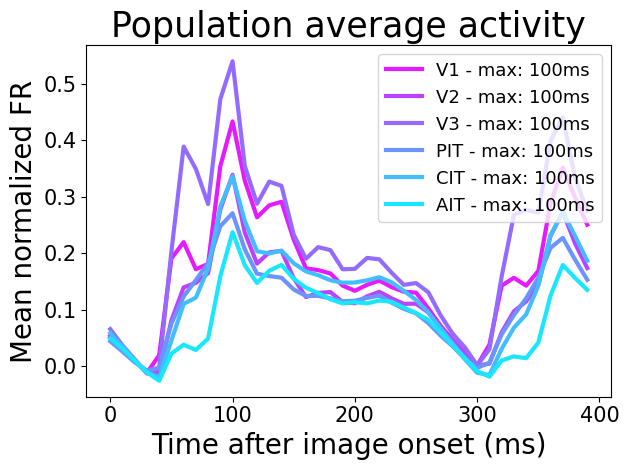

In [191]:
# visualize univariate activity
cmap = truncate_colormap(plt.cm.cool_r)
for idx, ba in enumerate(brain_areas):
    resp = ba_obj.slice_brain_area(natraster, ba)
    m = np.mean(resp.get_array(), axis=(0,2))
    # m_trials = np.mean(resp.get_array(), axis=2)
    # std = np.std(m_trials, axis=0)
    m_max = np.argmax(m)*1000/cfg.new_fs
    color=cmap(idx / (len(brain_areas) - 1))
    plt.plot(m, color=color, label=f"{ba} - max: {m_max:.0f}ms", linewidth=3,);
    # plt.fill_between(np.arange(m.shape[0]), m - std,m + std, color=color, alpha=0.3)
plt.xticks(np.arange(0, m.shape[0]+1, 10), np.arange(0, m.shape[0]+1, 10)*1000//cfg.new_fs, fontsize=cfg.ticks_fontsize)
plt.yticks(fontsize=cfg.ticks_fontsize)
plt.ylabel("Mean normalized FR", fontsize=cfg.labels_fontsize)
plt.xlabel("Time after image onset (ms)", fontsize=cfg.labels_fontsize)
plt.title("Population average activity", fontsize=cfg.title_fontsize)
plt.legend(loc='upper right', fontsize=cfg.legend_fontsize);
plt.tight_layout()
plt.savefig(f"{cfg.fig_dir}/avg_population_activity.pdf")

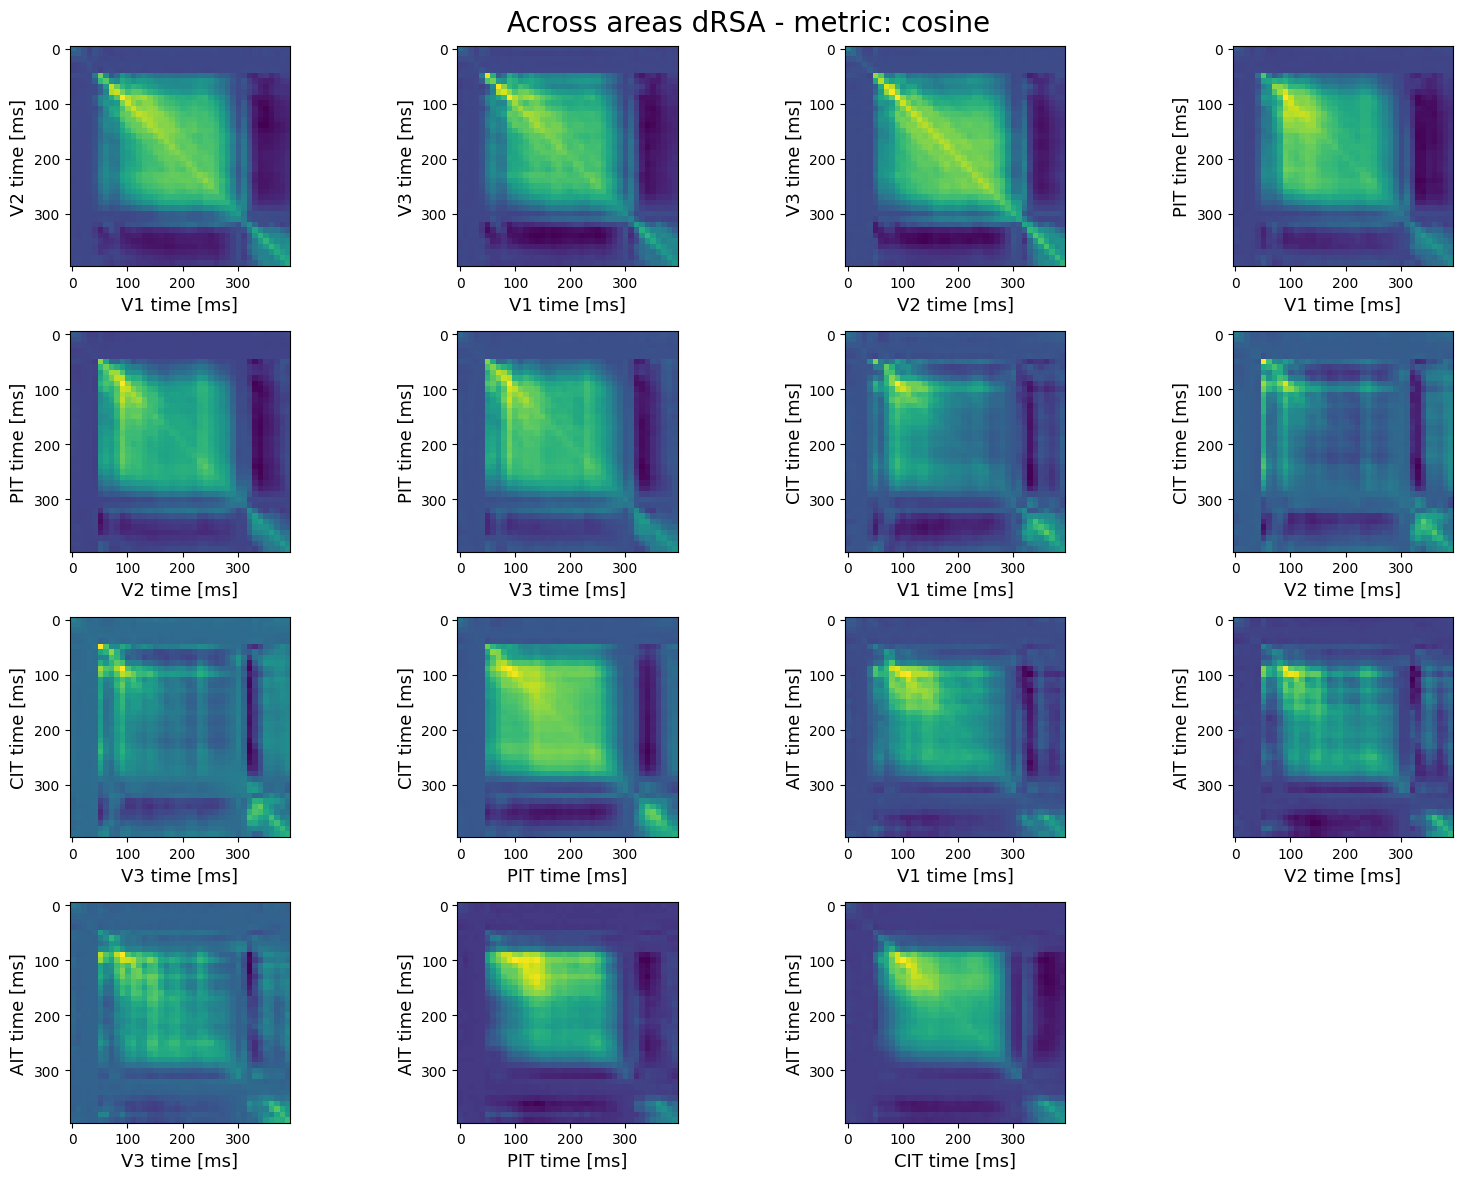

In [7]:

results_folder = f"{paths['livingstone_lab']}/tiziano/results"
ba_obj = BrainAreas(cfg.monkey_name)
brain_areas = ba_obj.get_brain_areas()
tasks_list = get_triu_perms(brain_areas)
n_cols = 4
n_rows = (len(tasks_list) + n_cols - 1) // n_cols  # ceil division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3))
axes = axes.flatten()
for idx, brain_areas_pair in enumerate(tasks_list):
    ax = axes[idx]
    drsa_mat = np.load(f"{results_folder}/{cfg.monkey_name}_{cfg.date}_{brain_areas_pair[0]}-{brain_areas_pair[1]}_images_{cfg.RDM_metric}_{cfg.new_fs}Hz.npz")['data']
    ax.imshow(drsa_mat)
    ax.set_xticks(np.arange(0, drsa_mat.shape[0], 10))
    ax.set_xticklabels(np.round(np.arange(0, drsa_mat.shape[0], 10)*1000/cfg.new_fs).astype(int))
    ax.set_yticks(np.arange(0, drsa_mat.shape[0], 10))
    ax.set_yticklabels(np.round(np.arange(0, drsa_mat.shape[0], 10)*1000/cfg.new_fs).astype(int))
    ax.set_ylabel(f"{brain_areas_pair[0]} time [ms]", fontsize=13)
    ax.set_xlabel(f"{brain_areas_pair[1]} time [ms]", fontsize=13)
    # ax.colorbar(label="Intensity")
fig.suptitle(f"Across areas dRSA - metric: {cfg.RDM_metric}", fontsize=20)
for i in range(len(tasks_list), len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

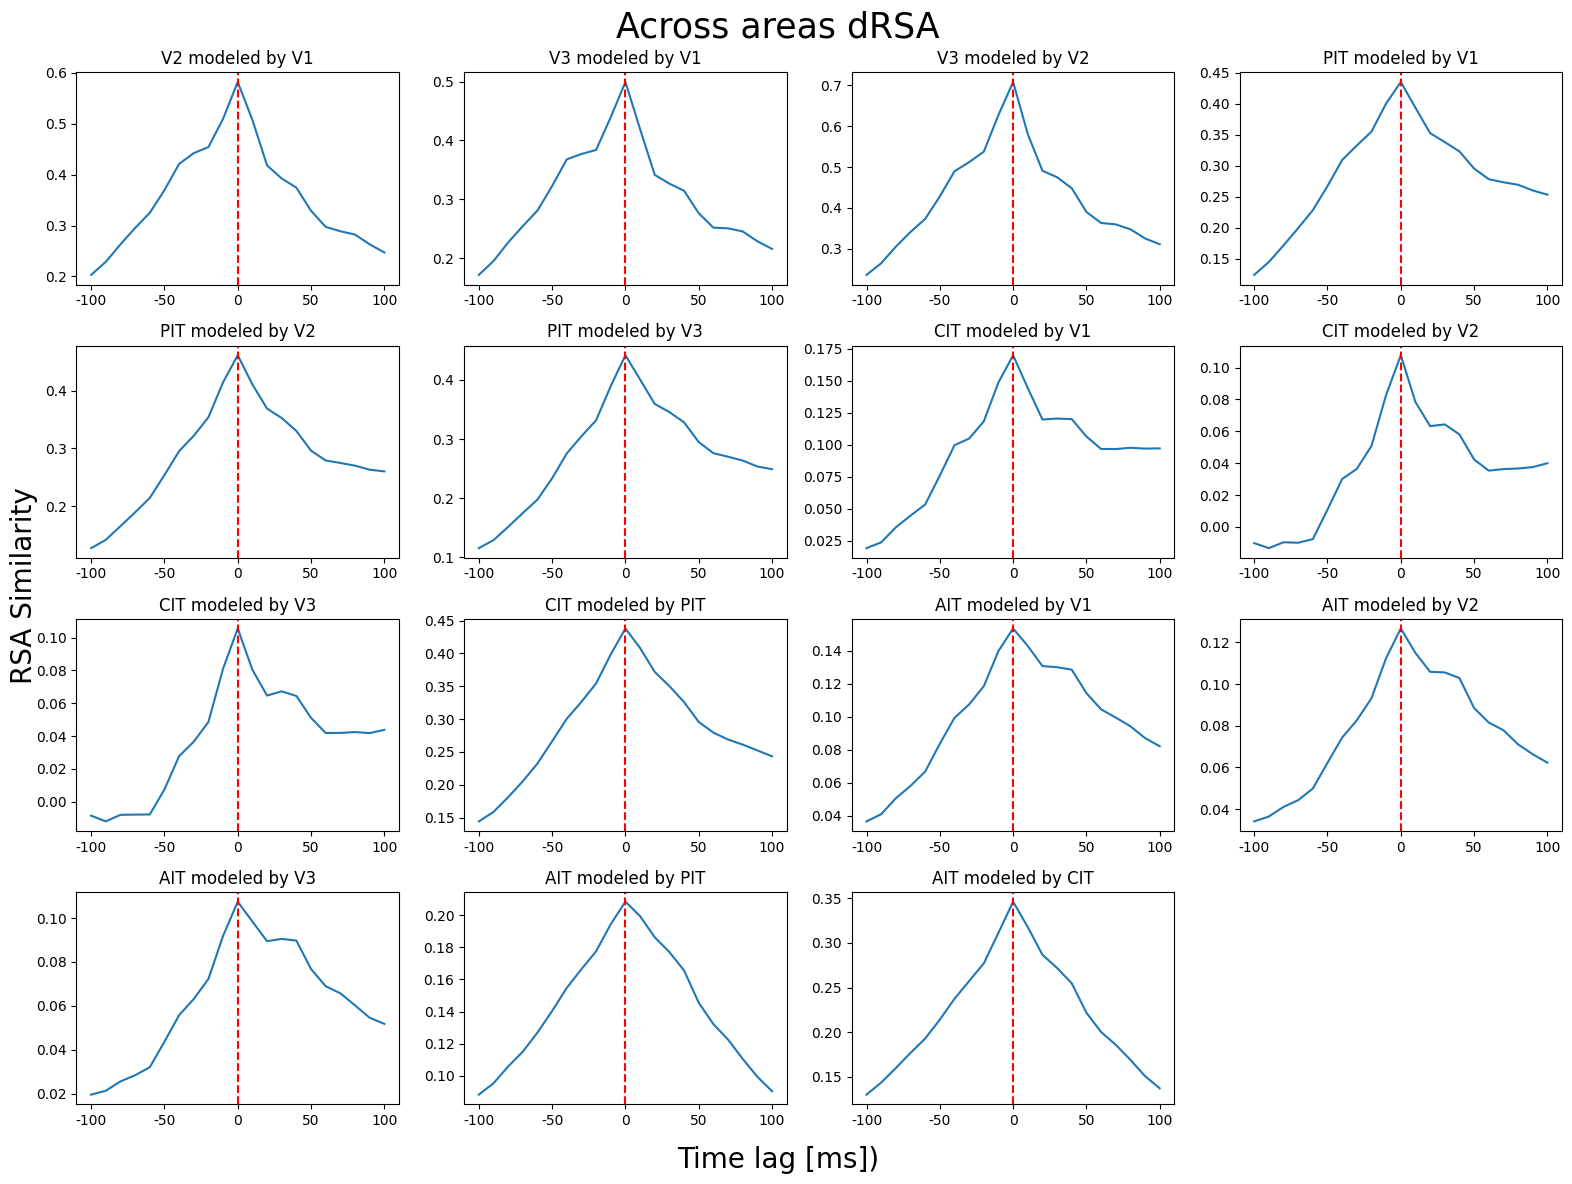

In [193]:
from general_utils.utils import get_lagplot_subset, get_lagplot

results_folder = f"{paths['livingstone_lab']}/tiziano/results"
ba_obj = BrainAreas(cfg.monkey_name)
brain_areas = ba_obj.get_brain_areas()
tasks_list = get_triu_perms(brain_areas)
lagplot_lims = (5, 30)
max_lag = 10
x_ticks = np.arange(0, 2*max_lag+1, 5)
x_ticks_labels = np.round(np.arange(-max_lag, max_lag+1, 5)*1000/cfg.new_fs).astype(int)
n_cols = 4
n_rows = (len(tasks_list) + n_cols - 1) // n_cols  # ceil division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3))
axes = axes.flatten()
for idx, brain_areas_pair in enumerate(tasks_list):
    ax = axes[idx]
    drsa_mat = np.load(f"{results_folder}/{cfg.monkey_name}_{cfg.date}_{brain_areas_pair[0]}-{brain_areas_pair[1]}_images_{cfg.RDM_metric}_{cfg.new_fs}Hz.npz")['data']
    ax.plot(get_lagplot_subset(drsa_mat,np.arange(*lagplot_lims), max_lag=max_lag));
    # ax.plot(get_lagplot(drsa_mat, max_lag=max_lag));
    ax.set_title(f"{brain_areas_pair[0]} modeled by {brain_areas_pair[1]}")
    ax.axvline(max_lag, color='r', linestyle='--')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticks_labels)
    # ax.set_ylabel("similarity")
    # ax.set_xlabel("lag [ms]")
for i in range(len(tasks_list), len(axes)):
    fig.delaxes(axes[i])
fig.suptitle(f"Across areas dRSA", fontsize=cfg.title_fontsize)
fig.supxlabel("Time lag [ms])", fontsize=cfg.labels_fontsize)
fig.supylabel("RSA Similarity", fontsize=cfg.labels_fontsize)
plt.tight_layout()
plt.savefig(f"{cfg.fig_dir}/across_areas_dRSA.pdf")
plt.show()

# Subsamples 

In [ ]:
fig, axes = plot_subsamples(paths, layers,cfg, ylim=[-.2, .6], save=True)
fig.savefig(f"{cfg.fig_dir}/subsampling_plot_AIT.pdf", dpi=300, bbox_inches="tight")
plt.close(fig)  # important when running in loops

In [27]:

def plot_RMSD(paths, layers, cfg, ylim = None, save=False):
    n_layers = len(layers)
    ncols = 4
    nrows = int(np.ceil(n_layers / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4*ncols, 3*nrows),
        sharex=True, sharey=True
    )
    axes = axes.flatten()

    base_cmap = plt.cm.turbo
    cmap = truncate_colormap(base_cmap, 0.10, 0.90)

    # n_samples = compute_samples_sizes(cfg)

    for ax, l in zip(axes, layers):
        file_name = (
            f"subsampling_{cfg.new_fs}Hz_{cfg.step_samples}-{cfg.max_size}_"
            f"{cfg.n_iter}iter_{cfg.monkey_name}_{cfg.date}_"
            f"{cfg.brain_area}_{cfg.RDM_metric}_{cfg.model_name}_{cfg.img_size}_{l}.npz"
        )
        results_path = f"{paths['livingstone_lab']}/tiziano/results/{file_name}"
        iter_dict = load_npz_as_dict(results_path)
        ground_truth = iter_dict[str(cfg.n_trials)]
        n_samples = len(iter_dict.keys())
        for idx, k in enumerate(iter_dict.keys()):
            color = cmap(idx / (n_samples - 1))
            squared_deviation = np.square(iter_dict[k] - ground_truth)
            if k != "4377":
                mean_squared_deviation = np.mean(squared_deviation, axis=0)
            else:
                mean_squared_deviation = squared_deviation
            stdev = np.sqrt(mean_squared_deviation)
            # perc = stdev/np.abs(ground_truth)
            ax.plot(stdev[:], color=color, linewidth=2)
            if l == layers[-1]: 
                ax.plot(stdev[:], color=color, label=f"{k} trials", linewidth=2)
            # plt.plot(np.mean((iter_dict[k] - ground_truth)**2, axis=0))
            ax.set_title(l, fontsize=12)
        # if l == layers[-1]:
        #     ax.plot(
        #         stdev,
        #         linewidth=2,
        #         label="all trials"
        #     )

    # remove unused axes
    for ax in axes[len(layers):]:
        ax.axis("off")

    fig.supxlabel("Time from image onset (ms)", fontsize=20)
    fig.supylabel("Root mean squared deviation", fontsize=20)
    fig.suptitle(f"Root mean squared deviation \n Brain area: {cfg.brain_area}", fontsize=27)
    fig.tight_layout()
    fig.legend(fontsize=13, bbox_to_anchor=(0.98, 0.90))
    # make space on the right for the legend
    fig.tight_layout(rect=[0.03, 0, 0.85, .97])
    # ax.set_xticks(xtickspos)           # positions of ticks
    # ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
    if ylim is not None:
        for ax in axes[:n_layers]:
            ax.set_ylim(ylim[0], ylim[1])
    xtickspos = range(0, len(iter_dict[str(cfg.n_trials)])+1, 10)       
    for ax in axes[:n_layers]:  # only the used axes
        ax.set_xticks(xtickspos)
        ax.set_xticklabels([int(xt*1000/cfg.new_fs) for xt in xtickspos], fontsize=15)
        ax.tick_params(axis='both', labelsize=15)
    if save==True:
        return fig, axes
    else:
        plt.show()


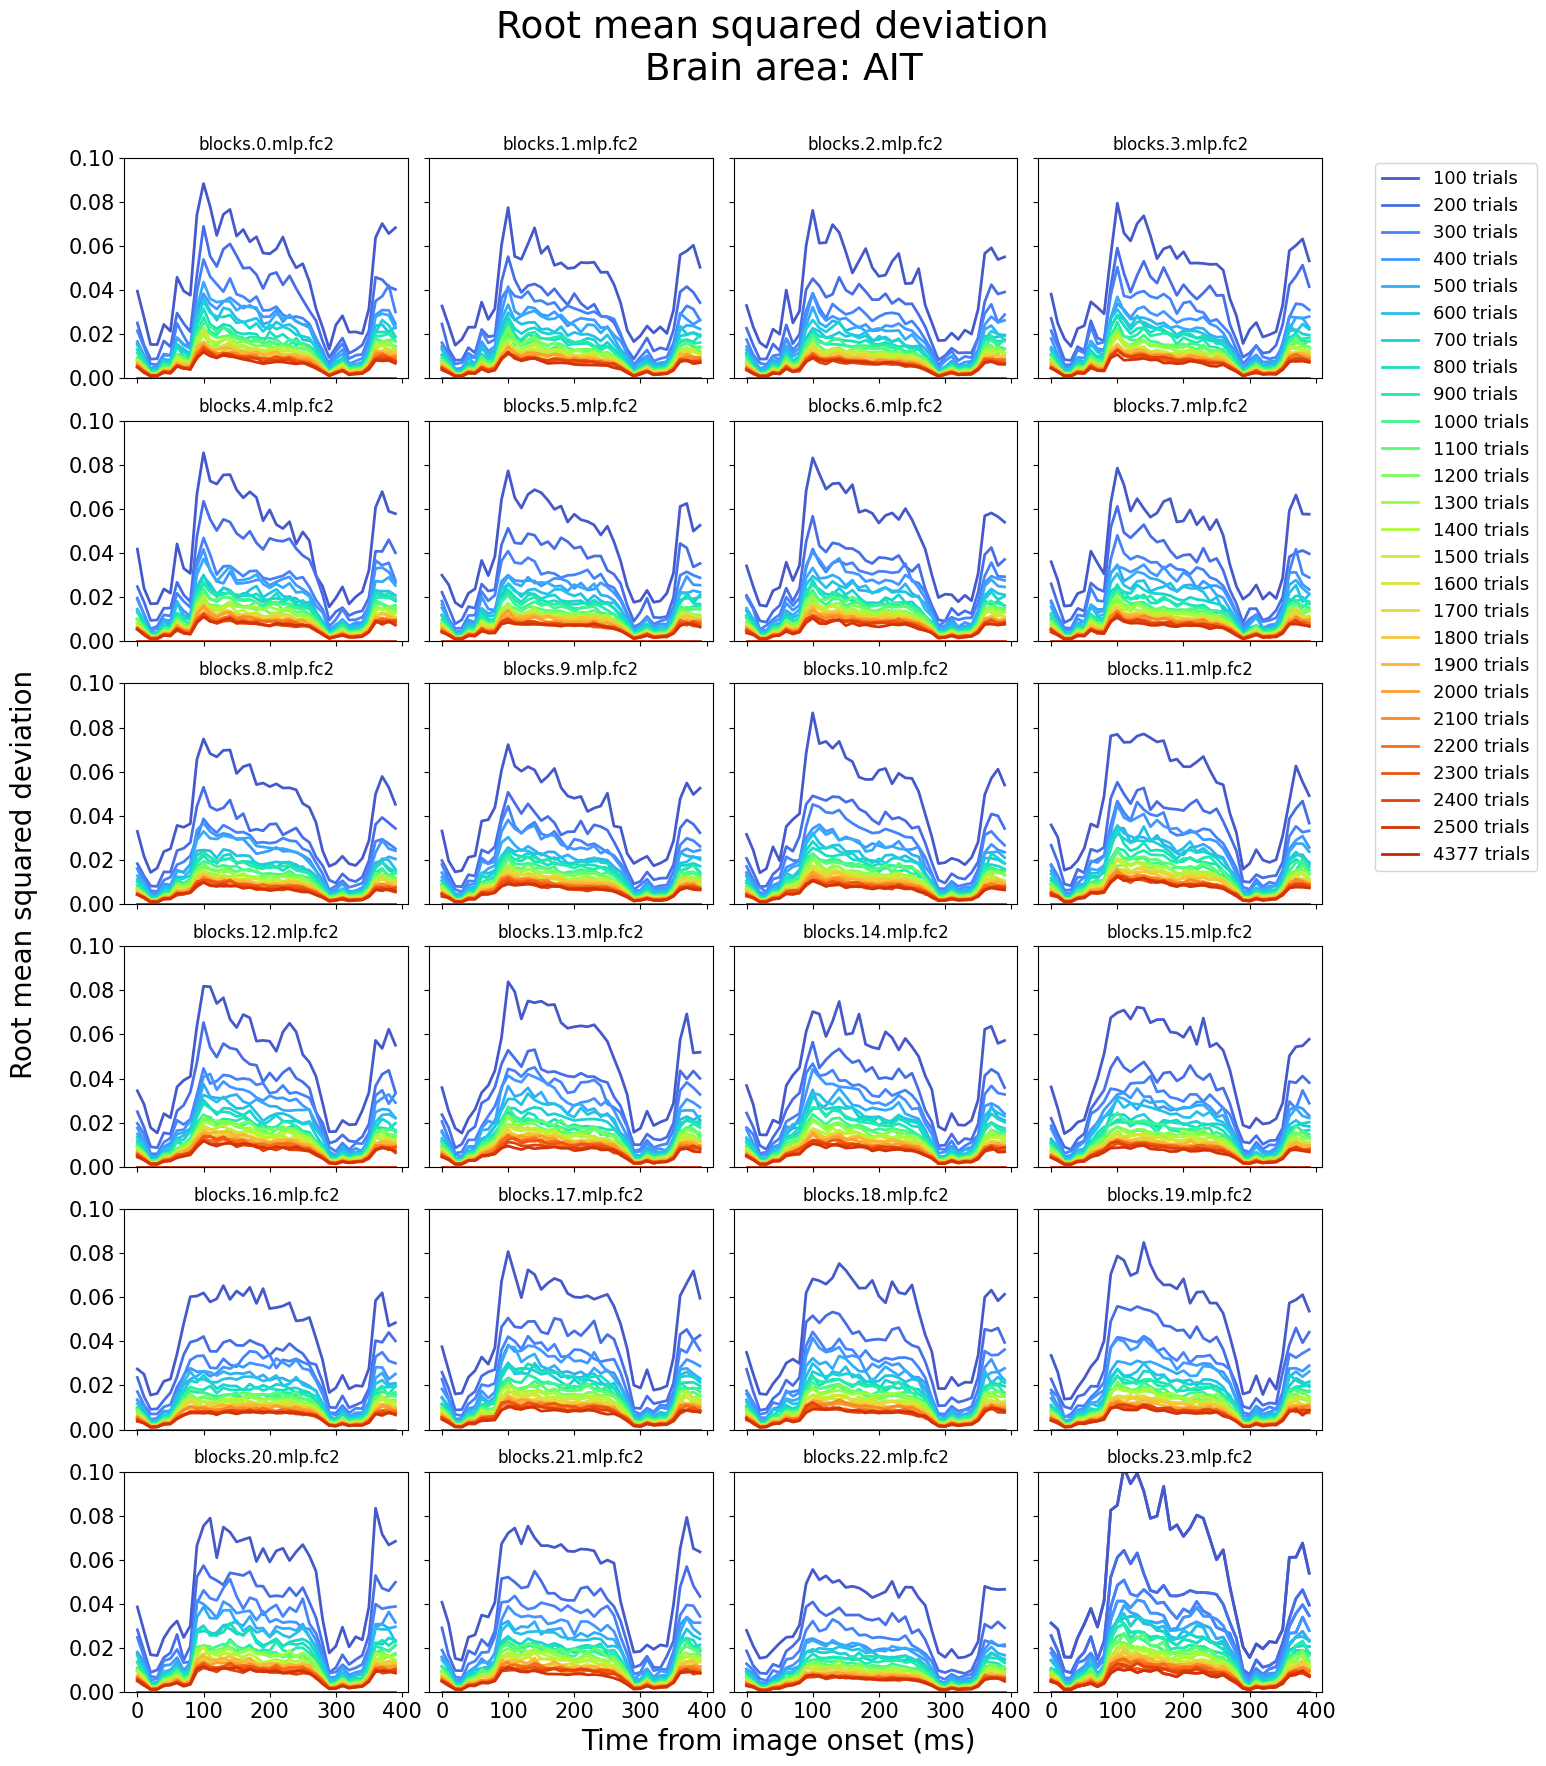

In [28]:
fig, axes = plot_RMSD(paths, layers, cfg, [0, .1], save=True)
fig.savefig(f"{cfg.fig_dir}/RMSD_{cfg.brain_area}.pdf", dpi=300, bbox_inches="tight")

In [14]:
# load the dict
file_name = (
    f"subsampling_{cfg.new_fs}Hz_{cfg.step_samples}-{cfg.max_size}_"
    f"{cfg.n_iter}iter_{cfg.monkey_name}_{cfg.date}_"
    f"{cfg.brain_area}_{cfg.RDM_metric}_{cfg.model_name}_{cfg.img_size}_{cfg.layer_name}.npz"
)
file_path = f"{paths['livingstone_lab']}/tiziano/results/{file_name}"
iter_dict = load_npz_as_dict(file_path)
ground_truth = iter_dict[str(cfg.n_trials)]

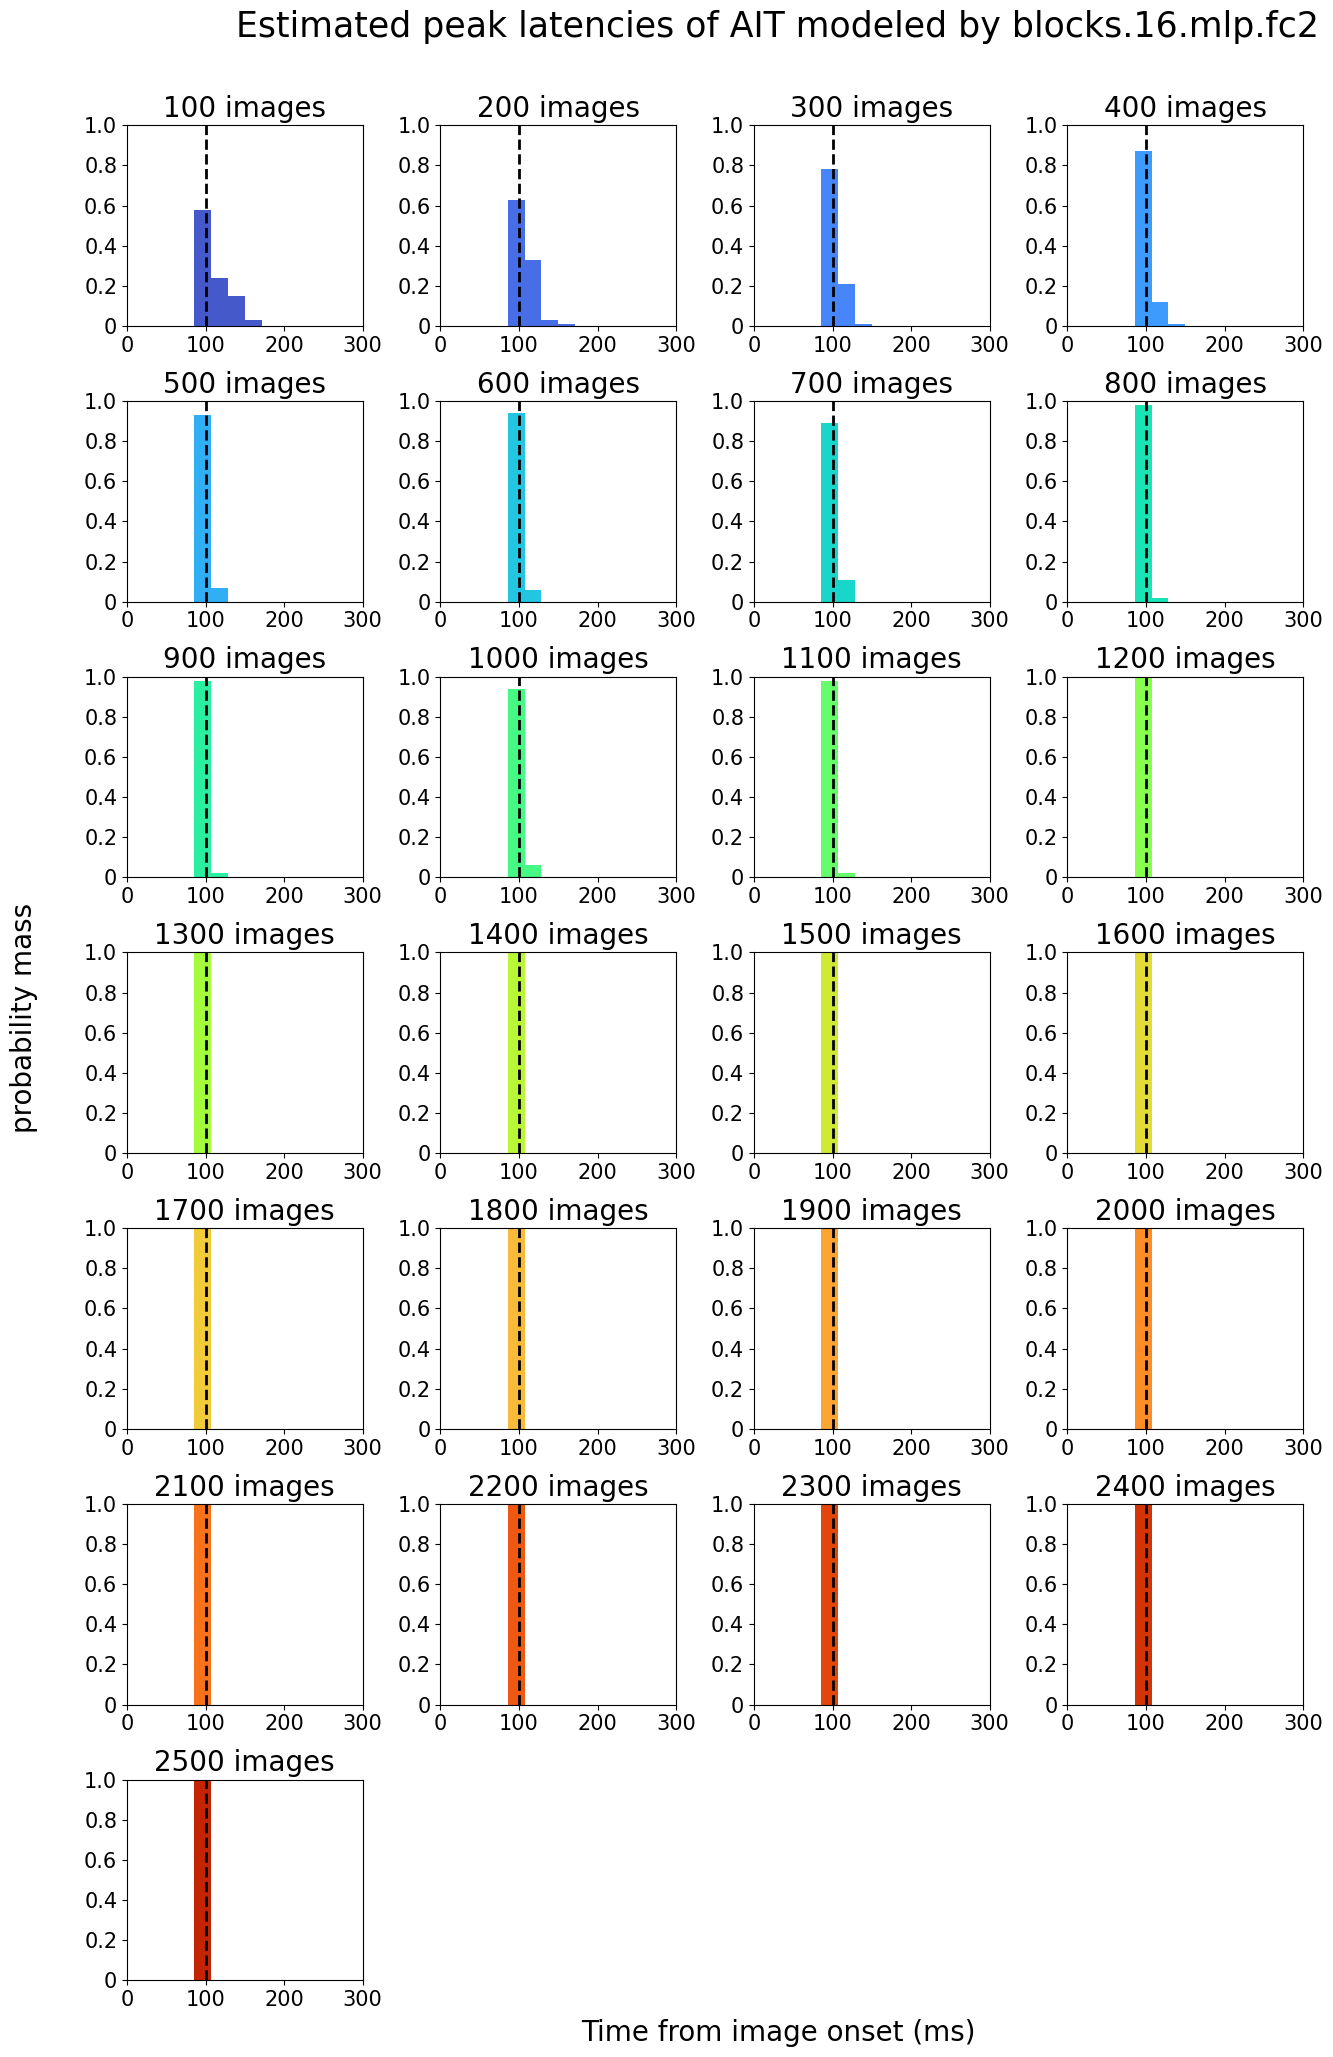

In [16]:
import matplotlib.pyplot as plt

base_cmap = plt.cm.turbo
cmap = truncate_colormap(base_cmap, 0.10, 0.90)
# plot the peaks
bins = np.linspace(0, 30, 15)  # number of bins
keys = list(iter_dict.keys())[:-1]
tot_keys_n = len(keys)
smoothing_factor = 3
# Determine grid size for subplots (e.g., square-ish layout)
n_cols = 4
n_rows = (tot_keys_n + n_cols - 1) // n_cols  # ceil division
x_ticks = np.arange(0, 31, 10)
x_ticks_labels = x_ticks*1000//cfg.new_fs
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3))
axes = axes.flatten()  # flatten to easily index

y_smooth = np.convolve(iter_dict[str(cfg.n_trials)], np.ones(smoothing_factor)/smoothing_factor, mode='same')
gt_latency = np.argmax(y_smooth)
for idx, k in enumerate(keys):
    color = cmap(idx / (tot_keys_n - 1))
    
    if k != "4377":
        curr = iter_dict[k][:,:30]
        curr_smooth = []
        for i in range(curr.shape[0]):
            y_smooth = np.convolve(curr[i,:], np.ones(smoothing_factor)/smoothing_factor, mode='same')    
            curr_smooth.append(y_smooth)
        # peak_latencies = np.argmax(iter_dict[k][:,:30], axis=1)
        curr_smooth = np.stack(curr_smooth, axis= 0 )
        peak_latencies = np.argmax(curr_smooth, axis=1)
    if k != "4377":    
        ax = axes[idx]
        ax.hist( peak_latencies, bins=bins, density=False, color=color)
        ax.axvline(x=gt_latency, color='k', linestyle='--', linewidth=2)
        ax.set_title(f"Key: {k}", fontsize=8)

        # ax.set_xlabel("Time points (10ms)", fontsize=8)
        # ax.set_ylabel("Density", fontsize=8)
        ax.set_xlim(0, 30)
        ax.set_ylim(0,100)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_ticks_labels, fontsize=cfg.ticks_fontsize)
        ax.set_yticks([0, 20, 40, 60, 80, 100])
        ax.set_yticklabels([0, .20, .40, .60, .80, 1.00], fontsize=cfg.ticks_fontsize)
        ax.set_title(f"{k} images", fontsize=cfg.labels_fontsize)
fig.suptitle(f"Estimated peak latencies of {cfg.brain_area} modeled by {cfg.layer_name}", fontsize=cfg.title_fontsize)
fig.supylabel("probability mass", fontsize=cfg.labels_fontsize)
fig.supxlabel("Time from image onset (ms)", fontsize=cfg.labels_fontsize)
# Turn off unused subplots (if any)
for i in range(tot_keys_n, len(axes)):
    fig.delaxes(axes[i])
fig.tight_layout(rect=[0.03, 0, 0.85, .97])
fig.savefig(f"{cfg.fig_dir}/peaks_PD_{cfg.brain_area}_{cfg.layer_name}.pdf", dpi=300, bbox_inches="tight")
plt.show()

## II corr-> cos

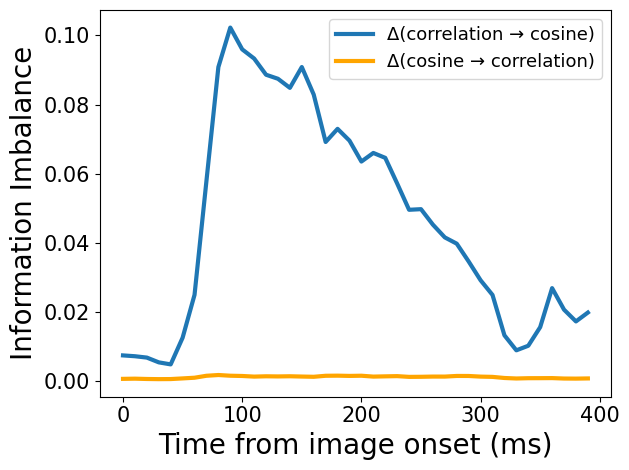

In [26]:
cfg.RDM_metric_A = "correlation"
cfg.RDM_metric_B = "cosine"
A2B_list = np.load(f"{paths['livingstone_lab']}/tiziano/results/II_{cfg.RDM_metric_A}2{cfg.RDM_metric_B}_{cfg.brain_area}.npz")["arr_0"]
B2A_list = np.load(f"{paths['livingstone_lab']}/tiziano/results/II_{cfg.RDM_metric_B}2{cfg.RDM_metric_A}_{cfg.brain_area}.npz")["arr_0"]
plt.plot(np.arange(0, len(A2B_list))*1000//cfg.new_fs,A2B_list, label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})", linewidth=3)
plt.plot(np.arange(len(A2B_list))*1000//cfg.new_fs, B2A_list, label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})", color="orange", linewidth=3)
plt.ylabel("Information Imbalance", fontsize=cfg.labels_fontsize)
plt.xlabel("Time from image onset (ms)", fontsize=cfg.labels_fontsize)
plt.legend(fontsize=cfg.legend_fontsize)
ax=plt.gca()
ax.tick_params(labelsize=cfg.ticks_fontsize)
plt.tight_layout()
plt.savefig(f"{cfg.fig_dir}/II_temporal.pdf")